## Resource-Constrained Project Scheduling Problem with Transfer Times

This notebook demonstrates how to model and solve the Resource-Constrained Project Scheduling Problem with Sequence-Dependent Setup Times
using Constraint Programming with IBM’s CP Optimizer via the [`docplex.cp`](https://ibmdecisionoptimization.github.io/docplex-doc/cp/refman.html) Python API.
This problem extends the classical RCPSP (see [`rcpsp.ipynb`](https://github.com/radovluk/CP_Cookbook/blob/main/notebooks/rcpsp.ipynb)). [CP formulation from Vilem Heinz](https://www.overleaf.com/1895916189bqhxjfkpwvws#151a3f).

### Problem Definiton

The Resource-Constrained Project Scheduling Problem with Transfer Times (RCPSPTT) is an extension of the RCPSP problem. In RCPSP, activities are executed using available resources, precedence relationships between them must be adhered to, and the total makespan is minimized. Compared to the RCPSP, RCPSPTT introduces transfer times between activities. This means that resources do not have to be directly available after the activity that uses them finishes; rather, a transfer of resources to the following activity might be required. The transfer time depends on both the activities and the resource transferred. Formally, the RCPSPTT problem is defined as follows: Let $\mathcal{A}=\{0,1,\ldots,\hat{A}\}$, $\ \hat{A}\in\mathbb{N}$, be a set of activities with indices $i,j\in\mathcal{A}$. Let $P\in\mathbb{N}^{|\mathcal{A}|}$ be a vector of activity processing times. Let $\mathcal{E}=\{(i,j)\mid \text{activity } i \text{ precedes activity } j\}$ be a set of precedences. Let $\mathcal{R}=\{0,1,\ldots,\hat{R}\}$, $\ \hat{R}\in\mathbb{N}$, be a set of primary resources indexed by $r\in\mathcal{R}$. Let $C\in\mathbb{N}^{|\mathcal{R}|}$ be a vector of primary resource capacities. Let $\mathbf{Q}\in\mathbb{Z}_{{\ge 0}}^{|\mathcal{A}|\times|\mathcal{R}|}$ be the activity–resource consumption matrix, with entries $\mathbf{Q}_{i,r}$ denoting the consumption of resource $r$ by activity $i$ ($i=0 \Rightarrow \mathbf{Q}_{i,r}=C_r$). Let $\Delta\in\mathbb{Z}_{\ge 0}^{|\mathcal{A}|\times|\mathcal{A}|\times|\mathcal{R}|}$ be a matrix of transfer delays, with entries $\Delta_{i,j,r}$ denoting the delay required if resource $r$ is transferred between activities $i$ and $j$. Let $\mathcal{T} \subseteq \mathcal{A} \times \mathcal{A} \times \mathcal{R}$ be the set of feasible resource transfers, where $(i,j,r) \in \mathcal{T}$ if: (i) $i \neq j$ (no self-transfers), (ii) $(j,i) \notin \mathcal{E}$ (no reverse precedence relationship), (iii) either $\mathbf{Q}_{i,r} > 0$ or $i = 0$ (source activity has resource $r$), (iv) either $\mathbf{Q}_{j,r} > 0$ or $j = |\mathcal{A}|-1$ (target activity needs resource $r$ or is sink).

### CP Formulation

$$
\begin{aligned}
\min \quad
& \operatorname{end}(a_{|\mathcal{A}|-1})
\qquad &\qquad & \text{(1)} \\[2mm]
\text{s.t.} \quad
& \operatorname{endBeforeStart}(a_i, a_j),
\qquad & \forall (i, j) \in \mathcal{E}
\quad & \text{(2)} \\[1mm]
& \sum_{j:(0, j, r) \in \mathcal{T}} f_{0, j, r} = C_r,
\qquad & \forall r \in \{0, \dots, |\mathcal{R}| - 1\}
\quad & \text{(3)} \\[1mm]
& f_{i,j,r} \ge 1 \implies \operatorname{presenceOf}(z_{i,j,r}) = 1,
\qquad & \forall (i, j, r) \in \mathcal{T}, \Delta_{i,j,r} = 0
\quad & \text{(4)} \\[2mm]
& f_{i,j,r} = \operatorname{heightAtStart}(z_{i,j,r}, \operatorname{pulse}(z_{i,j,r}, (0, U_{i,j,r}))),
\qquad & \forall (i, j, r) \in \mathcal{T}, \Delta_{i,j,r} > 0
\quad & \text{(5)} \\[2mm]
& \sum_{j:(j, i, r) \in \mathcal{T}} f_{j, i, r} = Q_{i, r},
\qquad & \forall i \in \{1, \dots, |\mathcal{A}| - 1\}, \forall r \in \{0, \dots, |\mathcal{R}| - 1\}
\quad & \text{(6)} \\[2mm]
& \sum_{j:(i, j, r) \in \mathcal{T}} f_{i, j, r} = Q_{i, r},
\qquad & \forall i \in \{1, \dots, |\mathcal{A}| - 2\}, \forall r \in \{0, \dots, |\mathcal{R}| - 1\}
\quad & \text{(7)} \\[2mm]
& \operatorname{endBeforeStart}(a_i, z_{i, j, r}) \land \operatorname{endBeforeStart}(z_{i, j, r}, a_j),
\qquad & \forall (i, j, r) \in \mathcal{T}
\quad & \text{(8)} \\[2mm]
& \sum_{i: Q_{i, r} > 0} \operatorname{pulse}(a_i, Q_{i, r}) + \sum_{\substack{(i, j, k) \in \mathcal{T}, \\ \Delta_{i, j, k} > 0, k=r}} \operatorname{pulse}(z_{i, j, r}, (0, U_{i, j, r})) \le C_r,
\qquad & \forall r \in \{0, \dots, |\mathcal{R}| - 1\}
\quad & \text{(9)} \\[2mm]
& a_i: \text{mandatory interval var, length } p_i,
\qquad & \forall i \in \mathcal{A}
\quad & \text{(10a)} \\[1mm]
& f_{i,j,r} \in \mathbb{Z}, f_{i,j,r} \in [0, U_{i,j,r}],
\qquad & \forall (i, j, r) \in \mathcal{T}
\quad & \text{(10b)} \\[1mm]
& z_{i,j,r}: \text{optional interval var, length } \Delta_{i,j,r},
\qquad & \forall (i, j, r) \in \mathcal{T}
\quad & \text{(10c)}
\end{aligned}
$$

**Objective:**
  - (1) Minimize the makespan (the end time of the final sink activity $a_{|\mathcal{A}|-1}$).

**Modeling Constraints:**
  - (2) Precedence relations: Enforces precedence relations $\mathcal{E}$ between activities, ensuring an activity must finish before its successor can start.
  - (3) Source flow initialization: Ensures the total resource flow $r$ from the source node (activity 0) via all transfers ($f_{0,j,r}$) equals the total resource capacity $C_r$.
  - (4) Transfer activation for instantaneous transfers: For instantaneous transfers ($\Delta_{i,j,r} = 0$), the transfer interval $z_{i,j,r}$ is present if and only if flow $f_{i,j,r} \geq 1$ exists.
  - (5) Flow-height linkage for durative transfers: For durative transfers ($\Delta_{i,j,r} > 0$), the flow variable $f_{i,j,r}$ is constrained to equal the height of the pulse function at the start of the transfer interval $z_{i,j,r}$.
  - (6) Flow conservation (into activity): Ensures the total resource $r$ received by activity $i$ (summed from all incoming transfers) equals its required quantity $Q_{i,r}$.
  - (7) Flow conservation (out of activity): Ensures the total resource $r$ sent from activity $i$ (summed via all outgoing transfers) equals the quantity $Q_{i,r}$ that the activity processed.
  - (8) Temporal linking: Enforces the time sequencing for transfers. A transfer $z_{i,j,r}$ must start after activity $a_i$ ends, and activity $a_j$ must start after transfer $z_{i,j,r}$ ends.
  - (9) Resource capacity (cumulative constraint): Ensures that at any point in time, the sum of resources consumed by all active activities and resources in transit during active durative transfers does not exceed the capacity $C_r$ for resource $r$.

**Variable Definitions:**
  - (10a) $a_i$: A mandatory interval variable representing the execution of activity $i$ with fixed length $p_i$.
  - (10b) $f_{i,j,r}$: An integer variable representing the amount of resource $r$ flowing from activity $i$ to activity $j$. For instantaneous transfers ($\Delta_{i,j,r}=0$), linked to presence via constraint (4). For durative transfers ($\Delta_{i,j,r}>0$), linked to the pulse height via constraint (5).
  - (10c) $z_{i,j,r}$: An optional interval variable representing the transfer of resource $r$ from activity $i$ to activity $j$, with fixed length $\Delta_{i,j,r}$.

**Helper Expressions:**
  - $\operatorname{pulse}(z_{i,j,r}, (0, U_{i,j,r}))$: Creates a step function over the interval $z_{i,j,r}$ with variable height in range $[0, U_{i,j,r}]$.
  - $\operatorname{heightAtStart}(z_{i,j,r}, \operatorname{pulse}(z_{i,j,r}, (0, U_{i,j,r})))$: Returns the height of the pulse function at the start of interval $z_{i,j,r}$. Returns 0 if $z_{i,j,r}$ is absent.

**Parameters (Input Data):**
  - $\mathcal{A}$: The set of activities (including source activity 0 and sink activity $|\mathcal{A}|-1$).
  - $\mathcal{E}$: The set of precedence relations (ordered pairs of activities).
  - $\mathcal{R}$: The set of primary resources.
  - $\mathcal{T}$: The set of feasible transfers (triples of source activity, target activity, resource).
  - $p_i$: The fixed processing time (duration) of activity $a_i$.
  - $C_r$: The maximum capacity available for resource $r$.
  - $\Delta_{i,j,r}$: The duration (delay) for a transfer $(i, j, r)$. If $\Delta_{i,j,r} = 0$, the transfer is instantaneous.
  - $U_{i,j,r}$: The upper bound (maximum flow capacity) of the transfer $(i, j, r)$.
  - $Q_{i,r}$: The quantity of resource $r$ required by/consumed by activity $i$ (with $Q_{0,r} = C_r$ for the source).

(1) Cílová funkce: Minimalizujeme konec poslední aktivity (supersink). Makespan — celková délka projektu.

(2) Precedenční vztahy: Pro každou hranu (i,j) v grafu precedencí musí aktivita i skončit dříve, než začne aktivita j. Standardní precedenční constraint, totožný v obou formulacích.

(3) Inicializace toku ze source: Všechny jednotky zdroje r začínají v supersource (aktivita 0). Součet toků ze source do všech navazujících aktivit musí být přesně C_r — celá kapacita. Tím se "napumpuje" tok do systému.

(4) Aktivace okamžitých přesunů: Pro přesuny s nulovým přepravním časem (Δ=0): pokud tok f_{i,j,r} ≥ 1 (tedy aspoň jedna jednotka teče z i do j), pak musí existovat přepravní interval z_{i,j,r}. Implikace — pokud tok je nulový, interval může být absent.

(5) Propojení toku a výšky pulsu (durativní přesuny): Pro přesuny s nenulovým přepravním časem (Δ>0): tok f_{i,j,r} se rovná výšce pulsní funkce na začátku přepravního intervalu z_{i,j,r}. Pulsní funkce pulse(z, (0, U)) vytváří obdélník s proměnnou výškou od 0 do U po dobu trvání intervalu z. Funkce heightAtStart vrátí tuto výšku. Tím se propojuje celočíselná hodnota toku s kumulativním profilem — kolik jednotek je "na cestě", tolik zabírá kapacitu.

(6) Konzervace toku — přítok: Do každé aktivity i (kromě source) musí přitéct přesně tolik jednotek zdroje r, kolik aktivita vyžaduje (Q_{i,r}). Jako Kirchhoffův zákon v elektrických obvodech: co vteče = co je potřeba.

(7) Konzervace toku — odtok: Z každé aktivity i (kromě source a sink) musí odtéct přesně tolik jednotek, kolik aktivita spotřebovala. Nic se neztrácí — každá jednotka musí pokračovat k další aktivitě.

(8) Temporální propojení přesunů: Přepravní interval z_{i,j,r} musí ležet časově mezi koncem aktivity i a začátkem aktivity j. Tedy: aktivita i skončí → probíhá přeprava (trvá Δ_{i,j,r}) → teprve pak může začít aktivita j. Toto je mechanismus, kterým se vynucují přepravní časy.

(9) Kumulativní kapacita: V každém časovém okamžiku nesmí součet zabraných jednotek překročit kapacitu C_r. Sčítají se dvě věci: běžící aktivity (pulse výšky Q_{i,r}) a probíhající přesuny (pulse s proměnnou výškou od 0 do U). Jednotka "na cestě" je nedostupná pro ostatní — zabírá kapacitu, i když zrovna nepracuje.

(10a) Hlavní intervaly: Povinné (mandatory) — každá aktivita musí proběhnout, s pevným trváním p_i.

(10b) Flow proměnné: Celá čísla od 0 do U_{i,j,r} (horní mez = min(Q_i, Q_j)). Určují, kolik jednotek zdroje r teče z aktivity i do j.

(10c) Přepravní intervaly: Volitelné (optional) — existují jen pokud tok existuje. Trvání = přepravní čas Δ_{i,j,r}.

#### Symbols and Notation

| Symbol / Function | Meaning | DOcplex reference | OptalCP reference |
|---|---|---|---|
| $\mathcal{A}$ | Set of activities (including source and sink) | — | — |
| $\mathcal{R}$ | Set of primary resources | — | — |
| $\mathcal{E}$ | Set of precedence relations; $(i,j) \in \mathcal{E}$ means activity $i$ must precede $j$ | — | — |
| $\mathcal{T}$ | Set of feasible resource transfers $(i,j,r)$ | — | — |
| $p_i$ | Processing time (duration) of activity $i$ | — | — |
| $C_r$ | Available capacity of resource $r$ | — | — |
| $\mathbf{Q}_{i,r}$ | Units of resource $r$ required by activity $i$ | — | — |
| $\Delta_{i,j,r}$ | Transfer delay (duration) for resource $r$ from activity $i$ to $j$ | — | — |
| $U_{i,j,r}$ | Upper bound (max flow capacity) for transfer $(i,j,r)$ | — | — |
| $a_i$ | Mandatory interval variable for activity $i$ | [docplex.cp.expression.interval_var](https://ibmdecisionoptimization.github.io/docplex-doc/cp/docplex.cp.expression.py.html#docplex.cp.expression.interval_var) | [Model.interval_var](http://dev.vilim.eu/python-api/api.html#optalcp.Model.interval_var) |
| $f_{i,j,r}$ | Integer variable: amount of resource $r$ flowing from $i$ to $j$ | [docplex.cp.modeler.integer_var](https://ibmdecisionoptimization.github.io/docplex-doc/cp/docplex.cp.modeler.py.html#docplex.cp.modeler.integer_var) | [Model.int_var](http://dev.vilim.eu/python-api/api.html#optalcp.Model.int_var) |
| $z_{i,j,r}$ | Optional interval variable for durative transfer of resource $r$ | [docplex.cp.expression.interval_var](https://ibmdecisionoptimization.github.io/docplex-doc/cp/docplex.cp.expression.py.html#docplex.cp.expression.interval_var) | [Model.interval_var](http://dev.vilim.eu/python-api/api.html#optalcp.Model.interval_var) |
| $\operatorname{end}(a_i)$ | End time of activity $i$ | [docplex.cp.modeler.end_of](https://ibmdecisionoptimization.github.io/docplex-doc/cp/docplex.cp.modeler.py.html#docplex.cp.modeler.end_of) | [Model.end](http://dev.vilim.eu/python-api/api.html#optalcp.Model.end) |
| $\operatorname{endBeforeStart}(a_i, a_j)$ | Enforce activity $j$ to start after activity $i$ ends | [docplex.cp.modeler.end_before_start](https://ibmdecisionoptimization.github.io/docplex-doc/cp/docplex.cp.modeler.py.html#docplex.cp.modeler.end_before_start) | [Model.end_before_start](http://dev.vilim.eu/python-api/api.html#optalcp.Model.end_before_start) |
| $\operatorname{pulse}(a_i, \mathbf{Q}_{i,r})$ | Time-varying usage: $\mathbf{Q}_{i,r}$ units during activity $i$ | [docplex.cp.modeler.pulse](https://ibmdecisionoptimization.github.io/docplex-doc/cp/docplex.cp.modeler.py.html#docplex.cp.modeler.pulse) | [Model.pulse](http://dev.vilim.eu/python-api/api.html#optalcp.Model.pulse) |
| $\operatorname{pulse}(z_{i,j,r}, f_{i,j,r})$ | Step function for transfer: contributes $f_{i,j,r}$ units during $z_{i,j,r}$ | [docplex.cp.modeler.pulse](https://ibmdecisionoptimization.github.io/docplex-doc/cp/docplex.cp.modeler.py.html#docplex.cp.modeler.pulse) | [Model.pulse](http://dev.vilim.eu/python-api/api.html#optalcp.Model.pulse) |
| $\operatorname{heightAtStart}(z, p)$ | Returns height of pulse function $p$ at start of interval $z$ | [docplex.cp.modeler.height_at_start](https://ibmdecisionoptimization.github.io/docplex-doc/cp/docplex.cp.modeler.py.html#docplex.cp.modeler.height_at_start) | *Not natively exposed* (Synchronize pulse height with `int_var` via `implies`) |
| $\operatorname{presenceOf}(z_{i,j,r})$ | Returns 1 if optional interval $z_{i,j,r}$ is present, else 0 | [docplex.cp.modeler.presence_of](https://ibmdecisionoptimization.github.io/docplex-doc/cp/docplex.cp.modeler.py.html#docplex.cp.modeler.presence_of) | [Model.presence](http://dev.vilim.eu/python-api/api.html#optalcp.Model.presence) |
| $\operatorname{if\_then}(c, t)$ / $c \Rightarrow t$ | Logical implication | [docplex.cp.modeler.if_then](https://ibmdecisionoptimization.github.io/docplex-doc/cp/docplex.cp.modeler.py.html#docplex.cp.modeler.if_then) | [Model.implies](http://dev.vilim.eu/python-api/api.html#optalcp.Model.implies) |
| $\sum$ (cumulative sum) | Sum of pulse functions | [docplex.cp.modeler.sum](https://ibmdecisionoptimization.github.io/docplex-doc/cp/docplex.cp.modeler.py.html#docplex.cp.modeler.sum) | [Model.sum](http://dev.vilim.eu/python-api/api.html#optalcp.Model.sum) |
| $\min \operatorname{end}(a_{\|\mathcal{A}\|-1})$ | Objective: minimize makespan | [docplex.cp.modeler.minimize](https://ibmdecisionoptimization.github.io/docplex-doc/cp/docplex.cp.modeler.py.html#docplex.cp.modeler.minimize) | [Model.minimize](http://dev.vilim.eu/python-api/api.html#optalcp.Model.minimize) |

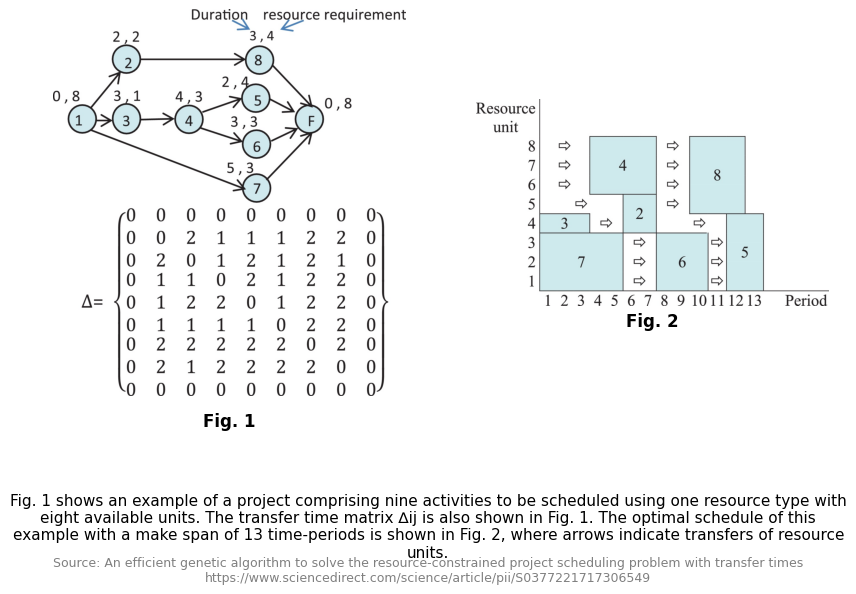

In [28]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import textwrap
img_problem = mpimg.imread('data/problem_visualisation.jpg')
img_solution = mpimg.imread('data/solution_visualisation.jpg')
fig, axes = plt.subplots(1, 2, figsize=(10, 7))
axes[0].imshow(img_problem)
axes[0].axis('off')
axes[0].set_title("Fig. 1", y=-0.1, fontsize=12, fontweight='bold')
axes[1].imshow(img_solution)
axes[1].axis('off')
axes[1].set_title("Fig. 2", y=-0.14, fontsize=12, fontweight='bold')
description = (
    "Fig. 1 shows an example of a project comprising nine activities to be scheduled "
    "using one resource type with eight available units. The transfer time matrix ∆ij "
    "is also shown in Fig. 1. The optimal schedule of this example with a make span "
    "of 13 time-periods is shown in Fig. 2, where arrows indicate transfers of resource units."
)
wrapped_description = textwrap.fill(description, width=110)
fig.text(0.5, 0.15, wrapped_description, ha='center', va='top', fontsize=11, wrap=True)
citation_text = (
    "Source: An efficient genetic algorithm to solve the resource-constrained project scheduling problem with transfer times\n"
    "https://www.sciencedirect.com/science/article/pii/S0377221717306549"
)
fig.text(0.5, 0.02, citation_text, ha='center', va='bottom', fontsize=9, color='gray')
plt.subplots_adjust(bottom=0.25)
plt.show()

### Data Import & Parsing

In [29]:
import re
from pathlib import Path

#### Parsing the data file

In [30]:
def parse_rcpsp_psplib(filepath):
    """
    Parses a .sm file (PSPLIB format for RCPSP with transfer times)
    and returns a dictionary with the project data.
    """
    with open(filepath, 'r') as f:
        content = f.read()

    data = {}
    match = re.search(r'jobs \(incl\. supersource/sink \):\s*(\d+)', content)
    data['n_jobs'] = int(match.group(1)) if match else 0
    match = re.search(r' - renewable\s*:\s*(\d+)', content)
    data['n_resources'] = int(match.group(1)) if match else 0
    n_jobs = data['n_jobs']
    n_res = data['n_resources']
    data['precedence_arcs'] = []
    prec_start = content.find('PRECEDENCE RELATIONS:')
    prec_end = content.find('****************', prec_start)
    prec_section = content[prec_start:prec_end]
    
    for line in prec_section.splitlines()[2:]:
        if not line.strip():
            continue
        parts = [int(p) for p in line.strip().split()]
        predecessor = parts[0]
        successors = parts[3:]
        for succ in successors:
            # Convert 1-based index from file to 0-based index
            data['precedence_arcs'].append((predecessor - 1, succ - 1))

    data['durations'] = []
    data['demands'] = []
    req_start = content.find('REQUESTS/DURATIONS:')
    req_end = content.find('****************', req_start)
    req_section = content[req_start:req_end]

    for line in req_section.splitlines()[3:]:
        if not line.strip():
            continue
        parts = [int(p) for p in line.strip().split()]
        data['durations'].append(parts[2])
        data['demands'].append(parts[3:]) # The rest are resource demands

    cap_start = content.find('RESOURCEAVAILABILITIES:')
    cap_end = content.find('****************', cap_start)
    cap_section = content[cap_start:cap_end]

    cap_line = cap_section.splitlines()[2]
    data['capacities'] = [int(p) for p in cap_line.strip().split()]
    data['transfer_times'] = []
    current_pos = cap_end

    for _ in range(n_res):
        tt_start = content.find('TRANSFERTIMES', current_pos)
        tt_end = content.find('****************', tt_start)
        tt_section = content[tt_start:tt_end]
        
        matrix = []
        lines = tt_section.splitlines()[3:]
        
        for i in range(n_jobs):
            line = lines[i]
            parts = [int(p) for p in line.strip().split()]
            matrix.append(parts[1:])
            
        data['transfer_times'].append(matrix)
        current_pos = tt_end
    return data

#### Helper functions and data structures

In [31]:
def compute_transitive_closure(edges, n_jobs):
    """
    Computes the transitive closure of the precedence graph using Floyd-Warshall algorithm. 
    Returns all precedence relationships (both direct and transitive) as (i, j) tuples.
    """
    adj = [[False] * n_jobs for _ in range(n_jobs)]
    for i, j in edges:
        adj[i][j] = True
    # Floyd-Warshall
    for k in range(n_jobs):
        for i in range(n_jobs):
            for j in range(n_jobs):
                adj[i][j] = adj[i][j] or (adj[i][k] and adj[k][j])
    return [(i, j) for i in range(n_jobs) for j in range(n_jobs) if adj[i][j]]

def compute_possible_transfers(abs_A, abs_R, Q, C, E, max_flow_limit=1000):
    """
    Generates the set T (feasible transfers) and calculates U (upper bounds).
    Returns: Dictionary mapping (i, j, r) -> U_ijr
    """
    T = {}
    E_set = set(E)  # Convert once for O(1) lookups
    for i in range(abs_A):
        for j in range(abs_A):
            if i == j or (j, i) in E_set:  # Skip self-transfers and reverse precedence
                continue
            for r in range(abs_R):
                # Check feasibility conditions
                source_has_resource = (i == 0 or Q[i][r] > 0)
                target_needs_resource = (j == abs_A - 1 or Q[j][r] > 0)
                if source_has_resource and target_needs_resource:
                    # Calculate upper bound U_ijr
                    max_flow = C[r] if i == 0 else min(Q[i][r], C[r])
                    T[(i, j, r)] = min(max_flow, max_flow_limit)
    return T

In [32]:
filename = "data/rcpsp_tt_instances/j301_a.sm"
filepath = Path(filename)

# Parse data
data = parse_rcpsp_psplib(filepath)
abs_A = data['n_jobs']
abs_R = data['n_resources']
p = data['durations']
C = data['capacities']  # List of capacities
Q = data['demands']  # List of lists (activity x resource demands)
E = compute_transitive_closure(data['precedence_arcs'], abs_A)

# This is IMPORTANT!
# Enforce Q[0,r] = Cr and Q[last,r] = Cr
Q[0] = C[:]
Q[abs_A - 1] = C[:]

# data['transfer_times'] is [resource][from_activity][to_activity]
Delta = []
for i in range(abs_A):
    Delta.append([])
    for j in range(abs_A):
        Delta[i].append([])
        for r in range(abs_R):
            Delta[i][j].append(data['transfer_times'][r][i][j])

T = compute_possible_transfers(abs_A, abs_R, Q, C, E)

### IBM CPO DOcplex Implementation

#### Imports

In [33]:
from docplex.cp.model import CpoModel

#### Create model and variables

In [34]:
mdl = CpoModel(name='rcpsptt_cpo')

# (10a): a_i (mandatory interval variables)
a = [mdl.interval_var(size=p[i], name=f'a_{i}') for i in range(abs_A)]

# (10b): f_{i,j,r} (integer flow variables)
f = {(i, j, r): mdl.integer_var(min=0, max=U_ijr, name=f'f_{i}_{j}_{r}')
     for (i, j, r), U_ijr in T.items()}

# (10c): z_{i,j,r}
z = {(i, j, r): mdl.interval_var(size=Delta[i][j][r], optional=True,
                                 name=f'z_{i}_{j}_{r}')
     for (i, j, r) in T.keys()}

In [35]:
# helper: store pulse expressions for cumulative constraint (Eq 9)
cumulative_contributions = {(i, j, r): mdl.pulse(z[(i, j, r)], (0, T[(i, j, r)]))
                            for (i, j, r) in T.keys() if Delta[i][j][r] > 0}

#### Add constraints and define objective

In [36]:
# (1): Minimize makespan
mdl.add(mdl.minimize(mdl.end_of(a[abs_A - 1])))

In [37]:
# (2) Precedence relations
mdl.add([mdl.end_before_start(a[i], a[j]) for i, j in E])

# (3) Source flow initialization
for r in range(abs_R):
    if outgoing := [f[(0, j, r)] for j in range(abs_A) if (0, j, r) in T]:
        mdl.add(mdl.sum(outgoing) == C[r])

# (4) Implication for instantaneous transfers (Delta = 0)
mdl.add(mdl.if_then(f[(i, j, r)] >= 1, mdl.presence_of(z[(i, j, r)]))
        for (i, j, r) in T.keys() if Delta[i][j][r] == 0)

# (5) Flow-height linkage for durative transfers
for (i, j, r), pulse in cumulative_contributions.items():
    mdl.add(f[(i, j, r)] == mdl.height_at_start(z[(i, j, r)], pulse))

# (6) Flow conservation (into activity)
for i in range(1, abs_A):
    for r in range(abs_R):
        if Q[i][r] > 0:
            if incoming := [f[(j, i, r)] for j in range(abs_A) if (j, i, r) in T]:
                mdl.add(mdl.sum(incoming) == Q[i][r])

# (7) Flow conservation (out of activity)
for i in range(1, abs_A - 1):
    for r in range(abs_R):
        if Q[i][r] > 0:
            if outgoing := [f[(i, j, r)] for j in range(abs_A) if (i, j, r) in T]:
                mdl.add(mdl.sum(outgoing) == Q[i][r])

# (8) Temporal linking for transfers
for (i, j, r) in T.keys():
    mdl.add(mdl.end_before_start(a[i], z[(i, j, r)]))
    mdl.add(mdl.end_before_start(z[(i, j, r)], a[j]))

# (9) Resource capacity (cumulative constraint)
for r in range(abs_R):
    activity_pulses = [mdl.pulse(a[i], Q[i][r]) for i in range(abs_A) if Q[i][r] > 0]
    transfer_pulses = [pulse for (i, j, res), pulse in cumulative_contributions.items() if res == r]
    if pulses := activity_pulses + transfer_pulses:
        mdl.add(mdl.sum(pulses) <= C[r])

#### Solve the model

In [38]:
print("Solving model...")
if solution := mdl.solve(TimeLimit=300, LogVerbosity='Quiet'):
    makespan = solution.get_objective_values()[0]
    print("\n" + "="*80)
    print(f"{'RCPSPTT SOLUTION':^80}")
    print("="*80)
    print(f"Instance: {filepath.name}")
    print(f"Jobs: {abs_A} | Resources: {abs_R} | Makespan: {solution.get_objective_values()}")
    print("="*80)

Solving model...

                                RCPSPTT SOLUTION                                
Instance: j301_a.sm
Jobs: 32 | Resources: 4 | Makespan: (57,)


#### Visualisation

In [39]:
print(f"\n{'ACTIVITY SCHEDULE':^80}\n{'-'*80}")
print(f"{'Job':<8} {'Start':<10} {'End':<10} {'Duration':<10} {'Resource Demands'}\n{'-'*80}")
for i in range(abs_A):
    s, e, dur = solution[a[i]].start, solution[a[i]].end, p[i]
    demands = " | ".join([f"R{r}:{Q[i][r]}" for r in range(abs_R) if Q[i][r] > 0]) or "—"
    print(f"a_{i:<5} {s:<10} {e:<10} {dur:<10} {demands}")
print(f"\n{'-'*80}\n{'RESOURCE TRANSFERS':^80}\n{'-'*80}")
active_transfers = []
for (i,j,r) in z.keys():
    try:
        trans, flow = solution[z[(i,j,r)]], solution[f[(i,j,r)]]
        if trans.is_present() and flow > 0:
            active_transfers.append((r, trans.start, i, j, trans.end, int(Delta[i,j,r]), flow))
    except: pass
if active_transfers:
    for r in range(abs_R):
        r_trans = sorted([t for t in active_transfers if t[0] == r], key=lambda x: x[1])
        if r_trans:
            print(f"\nResource R{r} (Cap: {C[r]}): {'Transfer':<12} {'Start':<8} {'End':<8} {'Δ':<6} {'Flow'}")
            for _, start, i, j, end, dur, flow in r_trans:
                print(f"  z_{i}_{j}_{r:<7} {start:<8} {end:<8} {dur:<6} {flow}")
    print(f"\nTotal: {len(active_transfers)} transfers")
else:
    print("  No active transfers (all instantaneous)")
print(f"\n{'-'*80}\n{'SOLUTION SUMMARY':^80}\n{'-'*80}")
print(f"  Makespan: {makespan} | Activities: {abs_A} | Transfers: {len(active_transfers)} | Resources: {abs_R} | Precedences: {len(E)}")
print("="*80 + "\n")


                               ACTIVITY SCHEDULE                                
--------------------------------------------------------------------------------
Job      Start      End        Duration   Resource Demands
--------------------------------------------------------------------------------
a_0     0          0          0          R0:11 | R1:12 | R2:9 | R3:9
a_1     0          4          4          R0:1
a_2     0          3          3          R3:2
a_3     0          10         10         R3:4
a_4     4          14         10         R2:1
a_5     40         45         5          R1:10
a_6     4          5          1          R1:3
a_7     7          14         7          R0:3
a_8     14         18         4          R3:1
a_9     42         47         5          R3:6
a_10    14         21         7          R3:6
a_11    21         31         10         R1:3
a_12    18         20         2          R1:7
a_13    26         30         4          R2:2
a_14    30         35        

### OptalCP Implementation

$$
\begin{aligned}
\min \quad
& \operatorname{end}(a_{|\mathcal{A}|-1})
\qquad &\qquad & \text{(1)} \\[2mm]
\text{s.t.} \quad
& \operatorname{endBeforeStart}(a_i, a_j),
\qquad & \forall (i, j) \in \mathcal{E}
\quad & \text{(2)} \\[1mm]
& \sum_{j:(0, j, r) \in \mathcal{T}} f_{0, j, r} = C_r,
\qquad & \forall r \in \{0, \dots, |\mathcal{R}| - 1\}
\quad & \text{(3)} \\[1mm]
& \operatorname{presenceOf}(f_{i,j,r}) = \operatorname{presenceOf}(z_{i,j,r}),
\qquad & \forall (i, j, r) \in \mathcal{T}
\quad & \text{(4)} \\[2mm]
& \sum_{j:(j, i, r) \in \mathcal{T}} f_{j, i, r} = Q_{i, r},
\qquad & \forall i \in \{1, \dots, |\mathcal{A}| - 1\}, \forall r \in \{0, \dots, |\mathcal{R}| - 1\}
\quad & \text{(5)} \\[2mm]
& \sum_{j:(i, j, r) \in \mathcal{T}} f_{i, j, r} = Q_{i, r},
\qquad & \forall i \in \{1, \dots, |\mathcal{A}| - 2\}, \forall r \in \{0, \dots, |\mathcal{R}| - 1\}
\quad & \text{(6)} \\[2mm]
& \operatorname{endBeforeStart}(a_i, z_{i, j, r}) \land \operatorname{endBeforeStart}(z_{i, j, r}, a_j),
\qquad & \forall (i, j, r) \in \mathcal{T}
\quad & \text{(7)} \\[2mm]
& \sum_{i: Q_{i, r} > 0} \operatorname{pulse}(a_i, Q_{i, r}) + \sum_{\substack{(i, j, k) \in \mathcal{T}, \\ \Delta_{i, j, k} > 0, k=r}} \operatorname{pulse}(z_{i, j, r}, f_{i,j,r}) \le C_r,
\qquad & \forall r \in \{0, \dots, |\mathcal{R}| - 1\}
\quad & \text{(8)} \\[2mm]
& a_i: \text{mandatory interval var, length } p_i,
\qquad & \forall i \in \mathcal{A}
\quad & \text{(9a)} \\[1mm]
& f_{i,j,r}: \text{optional integer var}, f_{i,j,r} \in [1, U_{i,j,r}],
\qquad & \forall (i, j, r) \in \mathcal{T}
\quad & \text{(9b)} \\[1mm]
& z_{i,j,r}: \text{optional interval var, length } \Delta_{i,j,r},
\qquad & \forall (i, j, r) \in \mathcal{T}
\quad & \text{(9c)}
\end{aligned}
$$

Changes from DOcplex to OptalCP formulation:

- **(4)**: Replaced `heightAtStart` (not available in OptalCP) with presence synchronization between flow variable and transfer interval. The original implication constraint `f ≥ 1 ⟹ presence(z)` is now redundant since `f ∈ [1, U]` and presence synchronization together ensure: transfer exists ⟺ flow is present ⟺ flow ≥ 1.
- **(8)**: Pulse height is now the flow variable `f_{i,j,r}` directly, instead of fixed range `(0, U_{i,j,r})`.
- **(9b)**: Flow variables `f_{i,j,r}` are now optional with domain `[1, U_{i,j,r}]` to enable presence synchronization.

(1) Cílová funkce: Totožná — minimalizujeme makespan.

(2) Precedence: Totožná.

(3) Inicializace toku ze source: Totožná.

(4) Synchronizace přítomnosti: ⚠️ Odlišné od CPO. OptalCP nemá heightAtStart, proto se propojení řeší jinak: flow proměnná f a přepravní interval z jsou oba optional a mají synchronizovanou přítomnost — buď oba existují, nebo oba neexistují. Toto platí pro všechny přesuny (nerozlišuje se Δ=0 vs Δ>0 jako v CPO). Protože f ∈ [1,U] (viz 9b), přítomnost f automaticky znamená tok ≥ 1.

(5) Konzervace toku — přítok: Totožná s CPO constraint (6). Do aktivity musí přitéct Q_{i,r} jednotek.

(6) Konzervace toku — odtok: Totožná s CPO constraint (7). Z aktivity musí odtéct Q_{i,r} jednotek.

(7) Temporální propojení: Totožná s CPO constraint (8). Přesun leží časově mezi zdrojovou a cílovou aktivitou.

(8) Kumulativní kapacita: ⚠️ Odlišné od CPO. Výška pulsu přepravního intervalu je přímo flow proměnná f_{i,j,r} (celé číslo), nikoli rozsah (0, U). To je elegantnější — solver přímo ví, kolik jednotek je na cestě, místo aby to odvozoval přes heightAtStart.

(9a) Hlavní intervaly: Totožné — mandatory, délka p_i.

(9b) Flow proměnné: ⚠️ Odlišné od CPO. Jsou optional s rozsahem [1, U] (ne [0, U]). Optionalita nahrazuje nulový tok — pokud přesun neexistuje, f je absent (místo f=0). Když f je present, hodnota je minimálně 1. Díky tomu funguje synchronizace přítomnosti v (4).

(9c) Přepravní intervaly: Totožné — optional, délka Δ_{i,j,r}.



#### Imports

In [40]:
import optalcp as cp

#### Create model and variables

In [41]:
mdl = cp.Model(name='rcpsptt_optal')

# (9a): a_i (mandatory interval variables)
a = [mdl.interval_var(length=p[i], name=f'a_{i}') for i in range(abs_A)]

# (9b): f_{i,j,r} (optional integer flow variables with min=1)
f = {(i, j, r): mdl.int_var(min=1, max=U_ijr, name=f'f_{i}_{j}_{r}', optional=True)
     for (i, j, r), U_ijr in T.items()}

# (9c): z_{i,j,r} (optional interval variables for transfers)
z = {(i, j, r): mdl.interval_var(length=Delta[i][j][r], optional=True,
                                 name=f'z_{i}_{j}_{r}')
     for (i, j, r) in T.keys()}

#### Add constraints and define objective

In [42]:
# (1): Minimize makespan
mdl.minimize(a[abs_A - 1].end())

In [43]:
# (2) Precedence relations
mdl.enforce([a[i].end_before_start(a[j]) for i, j in E])

# (3) Source flow initialization
for r in range(abs_R):
    if outgoing := [f[(0, j, r)] for j in range(abs_A) if (0, j, r) in T]:
        mdl.enforce(mdl.sum(outgoing) == C[r])

# (4) Presence synchronization: flow variable is present iff transfer interval is present
# This replaces heightAtStart - combined with f ∈ [1, U], it ensures:
# transfer exists ⟺ flow is present ⟺ flow ≥ 1
for (i, j, r) in T.keys():
    mdl.enforce(f[(i, j, r)].presence() == z[(i, j, r)].presence())

# (5) Flow conservation (into activity)
for i in range(1, abs_A):
    for r in range(abs_R):
        if Q[i][r] > 0:
            if incoming := [f[(j, i, r)] for j in range(abs_A) if (j, i, r) in T]:
                mdl.enforce(mdl.sum(incoming) == Q[i][r])

# (6) Flow conservation (out of activity)
for i in range(1, abs_A - 1):
    for r in range(abs_R):
        if Q[i][r] > 0:
            if outgoing := [f[(i, j, r)] for j in range(abs_A) if (i, j, r) in T]:
                mdl.enforce(mdl.sum(outgoing) == Q[i][r])

# (7) Temporal linking for transfers
for (i, j, r) in T.keys():
    mdl.enforce(a[i].end_before_start(z[(i, j, r)]))
    mdl.enforce(z[(i, j, r)].end_before_start(a[j]))

# (8) Resource capacity (cumulative constraint)
# Use int_var directly as pulse height - this replaces heightAtStart
for r in range(abs_R):
    activity_pulses = [mdl.pulse(a[i], Q[i][r]) for i in range(abs_A) if Q[i][r] > 0]
    transfer_pulses = [mdl.pulse(z[(i, j, r)], f[(i, j, r)]) 
                       for (i, j, res) in T.keys() 
                       if res == r and Delta[i][j][r] > 0]
    if all_pulses := activity_pulses + transfer_pulses:
        mdl.enforce(mdl.sum(all_pulses) <= C[r])

#### Solve the model

In [44]:
# Winning strategy - Use positional argument
params = {
    "timeLimit": 60,
    "nbWorkers": 8,
    "logLevel": 2,
    "logPeriod": 5,
    "searchType": "FDSDual",
    "noOverlapPropagationLevel": 4,
    "cumulPropagationLevel": 3,
    "reservoirPropagationLevel": 2
}

# Fix: Remove 'params=' keyword
result = mdl.solve(params)

if result.solution is not None:
    # Note: In OptalCP result.solution.get_objective() returns the objective value
    print(f"Makespan: {result.solution.get_objective()}")
else:
    print("No solution found")

────────────────────────────────────────────────────────────────────────────────
                         ScheduleOpt OptalCP [Academic]
                            Version 2026.2.0 (Linux)
                CPU: AMD Ryzen 5 5500U with (12 physical cores)
────────────────────────────────────────────────────────────────────────────────
Input parse time: 00:00
   nbWorkers = 8
   preset = Default              (auto: < 100,000 variables)
   searchType = FDSDual
   logPeriod = 5 seconds
   timeLimit = 60 seconds
   noOverlapPropagationLevel = 4
   cumulPropagationLevel = 3
   reservoirPropagationLevel = 2
Input: rcpsptt_optal
   236 integer variables, 268 interval variables, 986 constraints, 257kB
   00:00 Presolving..
Presolved:
   236 integer variables, 268 interval variables, 984 constraints, 238kB
   00:00 Presolve complete, starting search.
────────────────────────────────────────────────────────────────────────────────
   00:00 ↑ Lower bound 37 Worker 1
   00:00 ↑ Lower bound 38 Worker

### Setup-Time Formulation (Alternative)

Instead of modeling resource transfers as explicit flow variables and optional transfer intervals, we **decompose each resource into individual machine units** and model transfer times as **sequence-dependent setup times** using `no_overlap` with transition matrices.

**Key idea:** A resource $r$ with capacity $C_r$ is split into $C_r$ identical machines. Each task $i$ that needs $Q_{i,r}$ units of resource $r$ gets $C_r$ optional interval copies (one per machine), of which exactly $Q_{i,r}$ must be present. On each machine, a `no_overlap` constraint with a transition distance matrix ensures transfer times between consecutive tasks.

**Advantages over the flow formulation:**
- **Fewer variables:** $O(n \cdot \sum_r C_r)$ instead of $O(n^2 \cdot |\mathcal{R}|)$
- **Stronger propagation:** `no_overlap` with transitions is one of the most optimized global constraints in CP solvers
- **No flow variables** — resource routing is handled implicitly by the sequence ordering

#### Setup-Time CP Formulation

$$
\begin{aligned}
\min \quad
& \operatorname{end}(a_{|\mathcal{A}|-1})
\qquad &\qquad & \text{(S1)} \\[2mm]
\text{s.t.} \quad
& \operatorname{endBeforeStart}(a_i, a_j),
\qquad & \forall (i, j) \in \mathcal{E}
\quad & \text{(S2)} \\[1mm]
& \sum_{m=0}^{C_r - 1} \operatorname{presenceOf}(c_{i,r,m}) = Q_{i,r},
\qquad & \forall i \in \mathcal{A}_r, \forall r \in \mathcal{R}
\quad & \text{(S3)} \\[2mm]
& \operatorname{startAtStart}(a_i, c_{i,r,m}),
\qquad & \forall i \in \mathcal{A}_r, \forall r \in \mathcal{R}, \forall m \in \{0, \dots, C_r - 1\}
\quad & \text{(S4)} \\[2mm]
& \operatorname{noOverlap}(\sigma_{r,m}, \, \mathbf{D}_r),
\qquad & \forall r \in \mathcal{R}, \forall m \in \{0, \dots, C_r - 1\}
\quad & \text{(S5)} \\[2mm]
& a_i: \text{mandatory interval var, length } p_i,
\qquad & \forall i \in \mathcal{A}
\quad & \text{(S6a)} \\[1mm]
& c_{i,r,m}: \text{optional interval var, length } p_i,
\qquad & \forall i \in \mathcal{A}_r, \forall r \in \mathcal{R}, \forall m \in \{0, \dots, C_r - 1\}
\quad & \text{(S6b)} \\[1mm]
& \sigma_{r,m} = \operatorname{sequenceVar}(\{c_{i,r,m} \mid i \in \mathcal{A}_r\}),
\qquad & \forall r \in \mathcal{R}, \forall m \in \{0, \dots, C_r - 1\}
\quad & \text{(S6c)}
\end{aligned}
$$

**Objective:**
  - (S1) Minimize the makespan.

**Constraints:**
  - (S2) Precedence relations (same as flow formulation).
  - (S3) **Demand satisfaction:** For each task $i$ that requires $Q_{i,r}$ units of resource $r$, exactly $Q_{i,r}$ of its $C_r$ machine copies must be present. This replaces flow conservation constraints (3), (6), (7) from the flow formulation.
  - (S4) **Synchronization:** When a copy $c_{i,r,m}$ is present, it must start at the same time as the main interval $a_i$. Since both have the same length $p_i$, they are fully aligned. When the copy is absent, the constraint is automatically satisfied.
  - (S5) **No-overlap with transitions:** On each machine $m$ of resource $r$, the sequence variable $\sigma_{r,m}$ ensures that all present task copies do not overlap, and that a minimum transition distance $\mathbf{D}_r[i][j] = \Delta_{i,j,r}$ is maintained between the end of task $i$ and the start of task $j$. This is enforced between **all pairs**, not just direct neighbors. This single constraint replaces temporal linking (8) and cumulative capacity (9) from the flow formulation.

**Variables:**
  - (S6a) $a_i$: Main interval variable for activity $i$ (mandatory, length $p_i$).
  - (S6b) $c_{i,r,m}$: Optional copy of activity $i$ on machine $m$ of resource $r$ (length $p_i$).
  - (S6c) $\sigma_{r,m}$: Sequence variable over all task copies on machine $m$ of resource $r$.

**Additional notation:**
  - $\mathcal{A}_r = \{i \in \mathcal{A} \mid Q_{i,r} > 0\}$: The set of activities requiring resource $r$.
  - $\mathbf{D}_r$: The transition distance matrix for resource $r$, where $\mathbf{D}_r[i][j] = \Delta_{i,j,r}$.

(S1) Cílová funkce: Minimalizujeme konec poslední aktivity (supersink). To je makespan — celková délka projektu. Chceme, aby se všechna práce dokončila co nejdříve.

(S2) Precedenční vztahy: Pro každou hranu (i,j) v grafu precedencí musí aktivita i skončit dříve, než začne aktivita j. Například pokud montáž základů musí předcházet stavbě zdí, tato podmínka to vynucuje. Tyto vztahy jsou totožné s flow formulací — nemění se.

(S3) Poptávka po zdrojích: Každý zdroj r s kapacitou C_r si představíme jako C_r nezávislých strojů (m = 0, 1, ..., C_r−1). Aktivita i má na každém stroji volitelnou kopii c_{i,r,m}. Tato podmínka říká: součet přítomných kopií přes všechny stroje daného zdroje musí být přesně Q_{i,r} — tedy přesně tolik, kolik jednotek zdroje aktivita vyžaduje. Například pokud aktivita B potřebuje 2 jednotky zdroje s kapacitou 3, pak přesně 2 ze 3 kopií budou přítomné a solver rozhodne, které 2 to budou.

(S4) Synchronizace kopií: Pokud je kopie c_{i,r,m} přítomná, musí začínat ve stejný čas jako hlavní interval a_i. Tím se zajistí, že všechny přítomné kopie jedné aktivity na různých strojích běží synchronizovaně — začínají a končí ve stejný okamžik. Pokud je kopie nepřítomná (absent), podmínka se automaticky splní (vlastnost constraintu startAtStart), takže nepřítomné kopie ničemu nebrání.

(S5) Nepřekrývání s přepravními časy: Na každém stroji m každého zdroje r platí constraint noOverlap s přechodovou maticí D_r. Ten říká: žádné dvě přítomné aktivity na tomtéž stroji se nesmějí časově překrývat, a navíc mezi koncem aktivity i a začátkem aktivity j musí být mezera alespoň D_r[i][j] — tedy přepravní čas. Toto je klíčový constraint celé formulace — implicitně vynucuje přepravní časy bez potřeby explicitních flow proměnných. Solver sám rozhoduje o pořadí aktivit na stroji; sequenceVar pořadí neurčuje, pouze seskupuje intervaly. Důležité: přechodové časy se vynucují mezi všemi páry aktivit na stroji, nejen mezi přímými sousedy v sekvenci.

(S6a) Hlavní intervaly: Každá aktivita i má povinný (mandatory) interval a_i s pevným trváním p_i. Tento interval existuje vždy — reprezentuje samotné provádění aktivity. Je to "kotva", ke které se synchronizují kopie na strojích.

(S6b) Kopie na strojích: Pro každou aktivitu i, každý zdroj r a každý stroj m (0 až C_r−1) existuje volitelný (optional) interval c_{i,r,m} se stejným trváním p_i jako hlavní interval. Volitelnost znamená, že solver rozhoduje, zda tato kopie bude přítomná — tím implicitně přiřazuje aktivity na stroje. Množina A_r obsahuje jen aktivity, které zdroj r skutečně využívají (Q_{i,r} > 0).

(S6c) Sekvenční proměnné: Pro každý stroj m každého zdroje r se vytvoří sekvenční proměnná σ_{r,m}, která seskupí všechny kopie na tomto stroji do jedné množiny. Tato proměnná sama o sobě nic nevynucuje — je to jen kontejner, který se předá constraintu noOverlap v (S5). Pořadí intervalů v konstruktoru nemá vliv na řešení; solver volí optimální pořadí sám.

#### IBM CPO Setup-Time Implementation

In [45]:
from docplex.cp.model import CpoModel

mdl_setup = CpoModel(name='rcpsptt_cpo_setup')

# (S6a): a_i — mandatory interval variables
a = [mdl_setup.interval_var(size=p[i], name=f'a_{i}') for i in range(abs_A)]

# Build per-resource data structures
copies = {}   # copies[(i, r, m)] -> optional interval var
sequences = {} # sequences[(r, m)] -> sequence var

for r in range(abs_R):
    cap = C[r]
    tasks_r = [j for j in range(abs_A) if Q[j][r] > 0]
    if not tasks_r:
        continue

    # Transition matrix for resource r
    transitions = [[Delta[i_job][j_job][r] for j_job in tasks_r] for i_job in tasks_r]

    # (S6b): c_{i,r,m} — optional interval copies
    for j in tasks_r:
        for m in range(cap):
            copies[(j, r, m)] = mdl_setup.interval_var(
                size=p[j], optional=True, name=f'c_{j}_r{r}_m{m}')

    # (S3): Demand — exactly Q[j][r] copies must be present
    for j in tasks_r:
        mdl_setup.add(
            mdl_setup.sum(mdl_setup.presence_of(copies[(j, r, m)]) for m in range(cap)) == Q[j][r])

    # (S4): Synchronization — present copies aligned with main interval
    for j in tasks_r:
        for m in range(cap):
            mdl_setup.add(mdl_setup.start_at_start(a[j], copies[(j, r, m)]))

    # (S5): No-overlap with transition matrix on each machine
    # (S6c): Sequence variables
    n_tasks_r = len(tasks_r)
    for m in range(cap):
        machine_intervals = [copies[(j, r, m)] for j in tasks_r]
        seq = mdl_setup.sequence_var(machine_intervals, types=list(range(n_tasks_r)),
                                     name=f'seq_r{r}_m{m}')
        mdl_setup.add(mdl_setup.no_overlap(seq, transitions, is_direct=False))
        sequences[(r, m)] = seq

In [46]:
# (S1): Minimize makespan
mdl_setup.add(mdl_setup.minimize(mdl_setup.end_of(a[abs_A - 1])))

# (S2): Precedence relations
mdl_setup.add([mdl_setup.end_before_start(a[i], a[j]) for i, j in E])

#### Solve (IBM CPO Setup-Time)

In [47]:
print("Solving setup-time model with IBM CPO...")
if solution := mdl_setup.solve(TimeLimit=60, LogVerbosity='Quiet'):
    makespan = solution.get_objective_values()[0]
    print(f"Makespan: {int(makespan)}")
    print(f"Status: {solution.get_solve_status()}")
else:
    print("No solution found")

Solving setup-time model with IBM CPO...
Makespan: 57
Status: Feasible


#### OptalCP Setup-Time Implementation

In [48]:
import optalcp as cp

mdl_setup = cp.Model(name='rcpsptt_optal_setup')

# (S6a): a_i — mandatory interval variables
a = [mdl_setup.interval_var(length=p[i], name=f'a_{i}') for i in range(abs_A)]

# Build per-resource data structures
copies = {}    # copies[(i, r, m)] -> optional interval var
sequences = {} # sequences[(r, m)] -> sequence var

for r in range(abs_R):
    cap = C[r]
    tasks_r = [j for j in range(abs_A) if Q[j][r] > 0]
    if not tasks_r:
        continue

    # Transition matrix for resource r
    transitions = [[Delta[i_job][j_job][r] for j_job in tasks_r] for i_job in tasks_r]

    # (S6b): c_{i,r,m} — optional interval copies
    for j in tasks_r:
        for m in range(cap):
            copies[(j, r, m)] = mdl_setup.interval_var(
                length=p[j], optional=True, name=f'c_{j}_r{r}_m{m}')

    # (S3): Demand — exactly Q[j][r] copies must be present
    for j in tasks_r:
        mdl_setup.enforce(
            mdl_setup.sum(copies[(j, r, m)].presence() for m in range(cap)) == Q[j][r])

    # (S4): Synchronization — present copies aligned with main interval
    for j in tasks_r:
        for m in range(cap):
            mdl_setup.enforce(a[j].start_at_start(copies[(j, r, m)]))

    # (S5): No-overlap with transition matrix on each machine
    # (S6c): Sequence variables
    n_tasks_r = len(tasks_r)
    for m in range(cap):
        machine_intervals = [copies[(j, r, m)] for j in tasks_r]
        seq = mdl_setup.sequence_var(machine_intervals, types=list(range(n_tasks_r)),
                                     name=f'seq_r{r}_m{m}')
        mdl_setup.enforce(seq.no_overlap(transitions))
        sequences[(r, m)] = seq

In [49]:
# (S1): Minimize makespan
mdl_setup.minimize(a[abs_A - 1].end())

# (S2): Precedence relations
mdl_setup.enforce([a[i].end_before_start(a[j]) for i, j in E])

#### Solve (OptalCP Setup-Time)

In [50]:
params = {
    "timeLimit": 60,
    "nbWorkers": 8,
    "logLevel": 2,
    "logPeriod": 5,
}

result = mdl_setup.solve(params)

if result.solution is not None:
    print(f"Makespan: {result.solution.get_objective()}")
else:
    print("No solution found")

────────────────────────────────────────────────────────────────────────────────
                         ScheduleOpt OptalCP [Academic]
                            Version 2026.2.0 (Linux)
                CPU: AMD Ryzen 5 5500U with (12 physical cores)
────────────────────────────────────────────────────────────────────────────────
Input parse time: 00:00
   nbWorkers = 8
   preset = Default                  (auto: < 100,000 variables)
   logPeriod = 5 seconds
   timeLimit = 60 seconds
   noOverlapPropagationLevel = 4     (preset: Default)
   cumulPropagationLevel = 3         (preset: Default)
   Workers 0-3: searchType = LNS     (preset: Default)
   Workers 4-5: searchType = FDS     (preset: Default)
   Workers 6-7: searchType = FDSDual (preset: Default)
Input: rcpsptt_optal_setup
   0 integer variables, 417 interval variables, 670 constraints, 222kB
   00:00 Presolving..
Presolved:
   0 integer variables, 417 interval variables, 661 constraints, 167kB
   00:00 Presolve complete, sta

### Aditional Resources

- **Instances for RCPSPTT:** https://www2.informatik.uni-osnabrueck.de/kombopt/data/rcpsp/

- **For image of the problem instance see this article:** [An efficient genetic algorithm to solve the resource-constrained project scheduling problem with transfer times](https://www.sciencedirect.com/science/article/pii/S0377221717306549)

- [Problem defintion from Vilem Heinz](https://www.overleaf.com/1895916189bqhxjfkpwvws#151a3f).